In [25]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("shivamb/real-or-fake-fake-jobposting-prediction")

# print("Path to dataset files:", path)

In [ ]:
import pandas as pd
# import os

# # The path variable is available from the previous cell's output
# file_path = os.path.join(path, 'fake_job_postings.csv')

# Load the dataset into a pandas DataFrame
# df = pd.read_csv(file_path)

# path = "/fake_job_postings_augmented.csv"

df = pd.read_csv(f"fake_job_postings_augmented.csv")


## EDA

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29880 entries, 0 to 29879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               17880 non-null  float64
 1   title                29880 non-null  object 
 2   location             29534 non-null  object 
 3   department           18333 non-null  object 
 4   salary_range         14868 non-null  object 
 5   company_profile      26572 non-null  object 
 6   description          29879 non-null  object 
 7   requirements         27184 non-null  object 
 8   benefits             22668 non-null  object 
 9   telecommuting        29880 non-null  int64  
 10  has_company_logo     29880 non-null  int64  
 11  has_questions        29880 non-null  int64  
 12  employment_type      26409 non-null  object 
 13  required_experience  22830 non-null  object 
 14  required_education   21775 non-null  object 
 15  industry             24977 non-null 

In [28]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,5941.0,Full Stack Engineer,"US, CA, Palo Alto",NaN,NaN,Declara is focused on bringing data to life. O...,"Declara is looking for a super-sharp, ambitiou...",Strong (5+ years) experience in a dynamic lang...,NaN,0,1,1,NaN,NaN,NaN,NaN,NaN,0
1,NaN,Business Development Representative,"US, CO, Denver",Logistics,3000-6000 per month,Omega Marketing Associates is a full-service m...,As a Business Development Representative you w...,Excellent organisational and communication ski...,100% remote. Flexible schedule. Health coverag...,1,0,0,Temporary,Associate,Some College Coursework Completed,Staffing and Recruiting,Finance,1
2,12972.0,Senior Business Development Manager Europe,"DE, BY, Munich",NaN,NaN,hello worldtalents23_ drives the change in dig...,At our company we believe that unnecessarily w...,Ideally you already have many years of operati...,If you are passionate about the dynamic start-...,0,1,0,Full-time,NaN,NaN,NaN,NaN,0
3,NaN,Payment Coordinator – Remote,"US, MA, Boston",Administration,60000-85000,Quantum Services Inc is a global payment proce...,This role involves receiving international cli...,Personal or business bank account required. Ab...,Competitive processing fees. Fully remote work...,0,0,0,Temporary,Director,High School or equivalent,Staffing and Recruiting,Unknown,1
4,15673.0,Junior Data Analyst,"GB, RIC, Twickenham",NaN,20000-24000,With an exceptional record of over 50% growth ...,"WorldStores, the UK’s leading online retailer ...",Requirements:Idea on Google AdWords and PPC/PL...,NaN,0,1,0,Full-time,Entry level,Bachelor's Degree,Retail,Data Analyst,0


In [29]:
df['company_profile'][0]

"Declara\xa0is focused on bringing data to life. Our technology platform uses machine learning, search, algorithms and recommendations to develop learning paths for individuals, making learning a constant discovery.Learning isn't just our product, it's what we do everyday. Work with a small focused team. You'll push and be pushed. Tackle the toughest technical challenges as you create products that can transform organizations across the globe. Do something meaningful. We're changing how the world nurtures and develops talent. We are located in\xa0Palo\xa0Alto, Boise and Mexico."

In [30]:
df['description'][0]

'Declara is looking for a super-sharp, ambitious engineer who’s able to work across the stack. We’re a passionate team building an intelligent social collaboration platform. You’re a badass coder who loves understanding the whole stack, and jumps on anything – from simple CSS to API performance. Together we will make “learning” more universal, relevant, engaging, and accessible.'

In [31]:
df['requirements'][0]

'Strong (5+ years) experience in a dynamic language (i.e., Python, PHP, #URL_83ae520386ded6258d877a9fff0b0a63b8809ec57eb94d5aa6ae885521c53c5e#, etc.)Strong (5+ years) experience using and developing on Linux and/or FreeBSD.Experience with VM based languages (CLR or JVM languages like C#, Java, Scala, etc.)Good to strong (2+ years) SQL experience (MySQL, Postgres, etc.)Web HTM/Javascript development experience. Backbone and #URL_c55c0e0196aeae732958ef0b08de05e7a1916915e08ea9ac031a36e65a96ec66#, we love it!Comfortable in developing frameworks, architectures and leading the efforts of diverse teams.You learn fast, and dive into new things with enthusiasm.You are excited to change education and make the world a better place.You understand the tradeoff between general solutions and specific ones, and your implementations are always at the perfect level of abstraction (Okay, they’re not. But they’re close enough).You love writing code, and want to work with and develop others that do too.You

### Class Imbalance

In [32]:
df['fraudulent'].value_counts()

fraudulent
0    17014
1    12866
Name: count, dtype: int64

In [33]:
# Calculate value counts and normalize to get percentages
fraudulent_percentages = df['fraudulent'].value_counts(normalize=True) * 100

# Display the percentages
display(fraudulent_percentages)

fraudulent
0    56.941098
1    43.058902
Name: proportion, dtype: float64

### Missing Data

In [34]:
# Count missing values in each column
missing_values = df.isnull().sum()

# Display the missing values count
display(missing_values)

job_id                 12000
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

### Has_ Variables

In [35]:
df['has_salary'] = (~df['salary_range'].isna()).astype(int)
df['has_department'] = (~df['department'].isna()).astype(int)
df['has_benefits'] = (~df['benefits'].isna()).astype(int)
df['has_requirements'] = (~df['requirements'].isna()).astype(int)
df['has_experience'] = (~df['required_experience'].isna()).astype(int)
df['has_education'] = (~df['required_education'].isna()).astype(int)
df['has_industry'] = (~df['industry'].isna()).astype(int)
df['has_function'] = (~df['function'].isna()).astype(int)
df['has_employment_type'] = (~df['employment_type'].isna()).astype(int)
df['has_company_profile'] = (~df['company_profile'].isna()).astype(int)


In [36]:
important_fields = ['salary_range', 'department', 'company_profile',
                   'requirements', 'benefits', 'employment_type',
                   'required_experience', 'required_education',
                   'industry', 'function']

df['completeness_score'] = df[important_fields].notna().sum(axis=1)


In [ ]:
df['bare_bones'] = (
    (df['salary_range'].isna()) &
    (df['benefits'].isna()) &
    (df['department'].isna()) &
    (df['required_experience'].isna())
).astype(int)

# "No company info" pattern
df['no_company_info'] = (
    (df['company_profile'].isna()) &
    (df['industry'].isna()) &
    (df['has_company_logo'] == 0)
).astype(int)


In [38]:
fraud_by_completeness = df.groupby('completeness_score')['fraudulent'].agg(['mean', 'count'])

In [39]:
# For each "has_" feature, calculate fraud rate
for col in ['has_salary', 'has_department', 'has_benefits', 'has_requirements', 'has_experience', 'has_education', 'has_industry', 'has_function', 'has_employment_type', 'has_company_profile']:
    fraud_rate_present = df[df[col]==1]['fraudulent'].mean()
    fraud_rate_missing = df[df[col]==0]['fraudulent'].mean()


### Visualizations

Fraud Rate by Completeness Score:
                        mean  count
completeness_score                 
0                   0.221649    194
1                   0.036337    688
2                   0.102682   1305
3                   0.068772   1425
4                   0.057845   1383
5                   0.059025   1169
6                   0.025431   2202
7                   0.024879   3095
8                   0.033924   3331
9                   0.042783   2314
10                  0.945045  12774


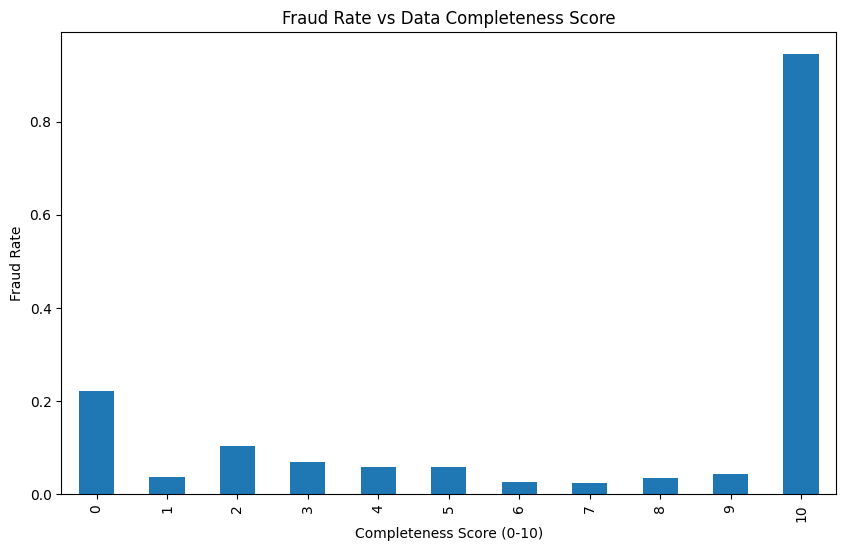

In [ ]:
print("Fraud Rate by Completeness Score:")
print(fraud_by_completeness)

import matplotlib.pyplot as plt
fraud_by_completeness['mean'].plot(kind='bar', figsize=(10,6))
plt.xlabel('Completeness Score (0-10)')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate vs Data Completeness Score')
plt.show()


In [41]:
print("\nFraud Rate Analysis by Feature Presence:")
print("-" * 60)
print(f"{'Feature':<25} {'Present':<15} {'Missing':<15} {'Diff':<10}")
print("-" * 60)

for col in ['has_salary', 'has_department', 'has_benefits', 'has_requirements',
            'has_experience', 'has_education', 'has_industry', 'has_function',
            'has_employment_type', 'has_company_profile']:

    fraud_rate_present = df[df[col]==1]['fraudulent'].mean()
    fraud_rate_missing = df[df[col]==0]['fraudulent'].mean()
    diff = fraud_rate_missing - fraud_rate_present

    print(f"{col:<25} {fraud_rate_present*100:>6.2f}%       {fraud_rate_missing*100:>6.2f}%      {diff*100:>+6.2f}%")



Fraud Rate Analysis by Feature Presence:
------------------------------------------------------------
Feature                   Present         Missing         Diff      
------------------------------------------------------------
has_salary                 82.21%         4.28%      -77.93%
has_department             67.28%         4.60%      -62.68%
has_benefits               55.15%         5.05%      -50.11%
has_requirements           46.76%         5.71%      -41.05%
has_experience             54.45%         6.17%      -48.28%
has_education              57.01%         5.56%      -51.45%
has_industry               50.41%         5.61%      -44.80%
has_function               53.49%         5.22%      -48.26%
has_employment_type        47.81%         6.94%      -40.86%
has_company_profile        46.21%        17.74%      -28.47%


In [42]:
from scipy.stats import chi2_contingency

print("\nChi-Square Tests for Missingness vs Fraud:")
print("-" * 60)

for col in ['has_salary', 'has_department', 'has_benefits', 'has_requirements']:
    contingency_table = pd.crosstab(df[col], df['fraudulent'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    print(f"{col}: Chi2={chi2:.2f}, p-value={p_value:.4e} {'***' if p_value < 0.001 else ''}")



Chi-Square Tests for Missingness vs Fraud:
------------------------------------------------------------
has_salary: Chi2=18497.87, p-value=0.0000e+00 ***
has_department: Chi2=11351.55, p-value=0.0000e+00 ***
has_benefits: Chi2=5600.31, p-value=0.0000e+00 ***
has_requirements: Chi2=1684.12, p-value=0.0000e+00 ***


In [43]:
print("\nPattern-Based Fraud Detection:")
print(f"Bare Bones Pattern: {df[df['bare_bones']==1]['fraudulent'].mean()*100:.2f}% fraud rate")
print(f"No Company Info Pattern: {df[df['no_company_info']==1]['fraudulent'].mean()*100:.2f}% fraud rate")
print(f"Overall fraud rate: {df['fraudulent'].mean()*100:.2f}%")

# Show counts
print(f"\nPostings matching 'bare_bones': {df['bare_bones'].sum()} ({df['bare_bones'].sum()/len(df)*100:.1f}%)")
print(f"Postings matching 'no_company_info': {df['no_company_info'].sum()} ({df['no_company_info'].sum()/len(df)*100:.1f}%)")



Pattern-Based Fraud Detection:
Bare Bones Pattern: 6.21% fraud rate
No Company Info Pattern: 24.45% fraud rate
Overall fraud rate: 43.06%

Postings matching 'bare_bones': 2671 (8.9%)
Postings matching 'no_company_info': 961 (3.2%)


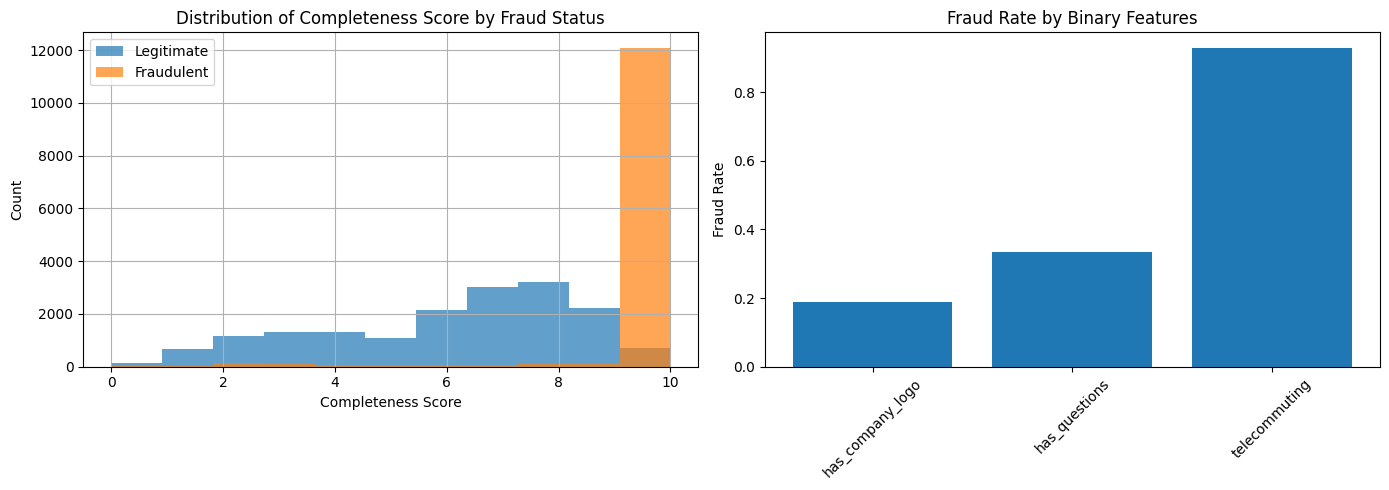

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

df[df['fraudulent']==0]['completeness_score'].hist(bins=11, alpha=0.7, label='Legitimate', ax=axes[0])
df[df['fraudulent']==1]['completeness_score'].hist(bins=11, alpha=0.7, label='Fraudulent', ax=axes[0])
axes[0].set_xlabel('Completeness Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Completeness Score by Fraud Status')
axes[0].legend()

# Binary features analysis
binary_cols = ['has_company_logo', 'has_questions', 'telecommuting']
fraud_rates = [df[df[col]==1]['fraudulent'].mean() for col in binary_cols]
axes[1].bar(binary_cols, fraud_rates)
axes[1].set_ylabel('Fraud Rate')
axes[1].set_title('Fraud Rate by Binary Features')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
df['completeness_squared'] = df['completeness_score'] ** 2
df['completeness_cubed'] = df['completeness_score'] ** 3

df['distance_from_safe_zone'] = df['completeness_score'].apply(
    lambda x: min(abs(x - 6), abs(x - 7))
)


In [ ]:
def categorize_risk_zone(score):
    if score == 0:
        return 'extreme_risk'  # 22% fraud rate
    elif score in [1]:
        return 'very_low_risk'  # 3.6% fraud rate
    elif score in [2]:
        return 'elevated_risk'  # 10% fraud rate
    elif score in [6, 7]:
        return 'low_risk'  # 2.5% fraud rate
    elif score == 10:
        return 'sophisticated_fraud_risk'  # 9.3% fraud rate
    else:
        return 'moderate_risk'  # ~4-6% fraud rate

df['risk_zone'] = df['completeness_score'].apply(categorize_risk_zone)


In [ ]:
df['too_perfect'] = (df['completeness_score'] == 10).astype(int)

df['extreme_completeness'] = (
    (df['completeness_score'] == 0) |
    (df['completeness_score'] == 10)
).astype(int)


In [ ]:
from scipy.stats import chi2_contingency

score_10_vs_baseline = pd.DataFrame({
    'fraud': [df[df['completeness_score']==10]['fraudulent'].sum(),
              df[df['completeness_score']!=10]['fraudulent'].sum()],
    'legit': [df[df['completeness_score']==10]['fraudulent'].count() -
              df[df['completeness_score']==10]['fraudulent'].sum(),
              df[df['completeness_score']!=10]['fraudulent'].count() -
              df[df['completeness_score']!=10]['fraudulent'].sum()]
})

chi2, p_value, _, _ = chi2_contingency(score_10_vs_baseline)
print(f"Score 10 vs Others: p-value = {p_value}")


Score 10 vs Others: p-value = 0.0
